# Checkpoint Winrate Analysis

This notebook parses a training output file produced by `logic/training.py`, extracts checkpoint evaluation win counts, computes win-rate statistics, and plots:

1. `current vs random` and `current vs heuristic` in one plot.
2. `current vs previous` in a separate plot (binary outcome per matchup).

In [1]:
# Print out td*.txt files in output directory
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)

OUTPUT_DIR = Path("output")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("logic/output")

if not OUTPUT_DIR.exists():
    print(f"Output directory not found: {OUTPUT_DIR.resolve()}")
else:
    txt_files = sorted(OUTPUT_DIR.glob("td*.txt"))
    print(f"td*.txt files in /logic/output/")
    if not txt_files:
        print("  (none found)")
    else:
        for f in txt_files:
            print(f"  - \"{f.name}\"")

td*.txt files in /logic/output/
  - "td_7.txt"
  - "td_cnn_10k.txt"
  - "td_hs1024_10k.txt"
  - "td_hs128_10k.txt"
  - "td_hs256.txt"
  - "td_hs256_10k.txt"
  - "td_hs512_10k.txt"
  - "td_hs512_20k.txt"
  - "td_hs512_4k.txt"
  - "td_hs512_5k.txt"
  - "td_hs768_10k.txt"
  - "td_lambda_hs1024_10k.txt"
  - "td_lambda_hs128_10k.txt"
  - "td_lambda_hs256_10k.txt"
  - "td_lambda_hs512_10k.txt"
  - "td_lambda_hs768_10k.txt"


In [2]:
# Specify the output file to parse.
OUTPUT_FILE = "td_hs256_10k.txt"
OUTPUT_PATH = Path(f"output/{OUTPUT_FILE}")

if not OUTPUT_PATH.exists():
    # Fallback for running the notebook from repository root.
    OUTPUT_PATH = Path(f"logic/output/{OUTPUT_FILE}")

print(f"Using output file: {OUTPUT_PATH}")

Using output file: output\td_hs256_10k.txt


## Extract Data

In [3]:
checkpoint_re = re.compile(r"--- Checkpoint evaluation after game (\d+) ---")
lineup_re = re.compile(r"^([A-Za-z]+) \(P1\) vs ([A-Za-z]+) \(P2\):")
counts_re = re.compile(r"([A-Za-z]+) wins: (\d+)")
best_ckpt_re = re.compile(r"\(from training game (\d+)\)")


def parse_checkpoint_output(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8")
    lines = text.splitlines()

    rows = []
    checkpoint = None
    section = None
    p1 = None
    p2 = None

    for raw in lines:
        line = raw.strip()

        m_cp = checkpoint_re.search(line)
        if m_cp:
            checkpoint = int(m_cp.group(1))
            continue

        if line in {"current vs random", "current vs heuristic", "current vs previous"}:
            section = line
            continue

        m_lineup = lineup_re.match(line)
        if m_lineup:
            p1, p2 = m_lineup.group(1).lower(), m_lineup.group(2).lower()
            continue

        if "wins:" in line and checkpoint is not None and section is not None and p1 and p2:
            parts = counts_re.findall(line)
            if len(parts) != 2:
                continue

            wins = {name.lower(): int(value) for name, value in parts}
            if "current" not in wins:
                continue

            opponent = p2 if p1 == "current" else p1
            rows.append(
                {
                    "checkpoint": checkpoint,
                    "matchup": section,
                    "opponent": opponent,
                    "p1": p1,
                    "p2": p2,
                    "current_wins": wins["current"],
                    "opponent_wins": wins.get(opponent, 0),
                }
            )

    if not rows:
        raise ValueError("No checkpoint matchup rows were parsed. Check the output format/path.")

    df = pd.DataFrame(rows)
    df["games"] = df["current_wins"] + df["opponent_wins"]
    df["current_win_rate"] = df["current_wins"] / df["games"]
    return df


def parse_best_checkpoint_game(path: Path) -> int | None:
    text = path.read_text(encoding="utf-8")
    matches = best_ckpt_re.findall(text)
    return int(matches[-1]) if matches else None


best_checkpoint_game = parse_best_checkpoint_game(OUTPUT_PATH)
if best_checkpoint_game is not None:
    print(f"Best checkpoint selected from training game: {best_checkpoint_game}")


df_raw = parse_checkpoint_output(OUTPUT_PATH)
df_raw.head(7)

Best checkpoint selected from training game: 1900


,checkpoint,matchup,opponent,p1,p2,current_wins,opponent_wins,games,current_win_rate
0,100,current vs random,random,current,random,36,14,50,0.72
1,100,current vs random,random,random,current,30,20,50,0.60
2,100,current vs heuristic,heuristic,current,heuristic,12,38,50,0.24
3,100,current vs heuristic,heuristic,heuristic,current,3,47,50,0.06
4,100,current vs previous,previous,current,previous,1,0,1,1.00
5,100,current vs previous,previous,previous,current,1,0,1,1.00
6,200,current vs random,random,current,random,39,11,50,0.78


In [4]:
# Aggregate by checkpoint + matchup (combines both side assignments).
df_agg = (
    df_raw.groupby(["checkpoint", "matchup", "opponent"], as_index=False)
    .agg(current_wins=("current_wins", "sum"), opponent_wins=("opponent_wins", "sum"), games=("games", "sum"))
)
df_agg["current_win_rate"] = df_agg["current_wins"] / df_agg["games"]

df_agg.head(4)

,checkpoint,matchup,opponent,current_wins,opponent_wins,games,current_win_rate
0,100,current vs heuristic,heuristic,15,85,100,0.15
1,100,current vs previous,previous,2,0,2,1.00
2,100,current vs random,random,66,34,100,0.66
3,200,current vs heuristic,heuristic,5,95,100,0.05


## Statistics

In [5]:
# Win-rate summary statistics per matchup.
stats = (
    df_agg.groupby("matchup")["current_win_rate"]
    .agg(["mean", "std", "min", "max"])
    .rename(columns={
        "mean": "mean_win_rate",
        "std": "std_win_rate",
        "min": "min_win_rate",
        "max": "max_win_rate",
    })
    .sort_index()
)

stats

,mean_win_rate,std_win_rate,min_win_rate,max_win_rate
matchup,,,,
current vs heuristic,0.3545,0.118316,0.05,0.63
current vs previous,0.6500,0.313823,0.00,1.00
current vs random,0.8718,0.063028,0.60,0.96


In [6]:
# Win rates at the final checkpoint.
final_checkpoint = int(df_agg["checkpoint"].max())
final_agg = (
    df_agg[df_agg["checkpoint"] == final_checkpoint]
    [["matchup", "current_wins", "opponent_wins", "games", "current_win_rate"]]
    .sort_values("matchup")
    .reset_index(drop=True)
)

print(f"Final checkpoint: {final_checkpoint}")
final_agg

Final checkpoint: 10000


,matchup,current_wins,opponent_wins,games,current_win_rate
0,current vs heuristic,43,57,100,0.43
1,current vs previous,1,1,2,0.50
2,current vs random,89,11,100,0.89


## Plots

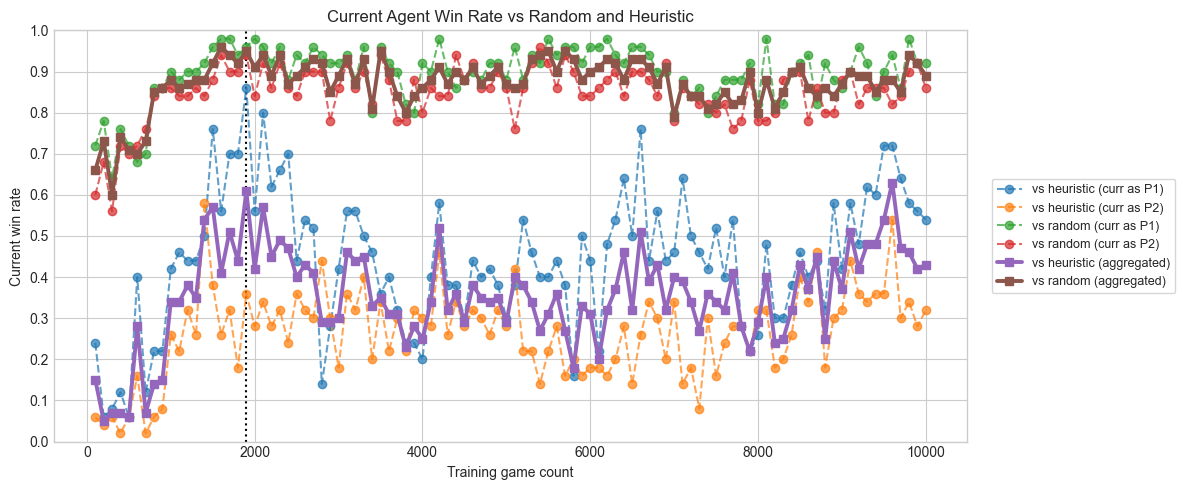

In [7]:
# Plot 1: current vs random/heuristic with directional and aggregated win rates.
fig, ax = plt.subplots(figsize=(15, 5))

if best_checkpoint_game is not None:
    ax.axvline(best_checkpoint_game, color="black", linestyle=":", linewidth=1.5, zorder=0)

plot_matchups = ["current vs random", "current vs heuristic"]
matchup_label = {"current vs random": "vs random", "current vs heuristic": "vs heuristic"}
perspective_label = {"Current as P1": "curr as P1", "Current as P2": "curr as P2"}
plot_df_raw = df_raw[df_raw["matchup"].isin(plot_matchups)].copy()
plot_df_agg = df_agg[df_agg["matchup"].isin(plot_matchups)].copy()

# Directional rates: current as P1 and current as P2 (50 games each).
plot_df_raw["perspective"] = np.where(plot_df_raw["p1"] == "current", "Current as P1", "Current as P2")
for (matchup, perspective), group in plot_df_raw.groupby(["matchup", "perspective"]):
    ax.plot(
        group["checkpoint"],
        group["current_win_rate"],
        marker="o",
        linestyle="--",
        alpha=0.7,
        zorder=3,
        label=f"{matchup_label[matchup]} ({perspective_label[perspective]})",
    )

# Aggregated rate across both directions (100 games).
for matchup, group in plot_df_agg.groupby("matchup"):
    ax.plot(
        group["checkpoint"],
        group["current_win_rate"],
        marker="s",
        linewidth=2.8,
        zorder=4,
        label=f"{matchup_label[matchup]} (aggregated)",
    )

ax.set_title("Current Agent Win Rate vs Random and Heuristic")
ax.set_xlabel("Training game count")
ax.set_ylabel("Current win rate")
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=1, fontsize=9, frameon=True)
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

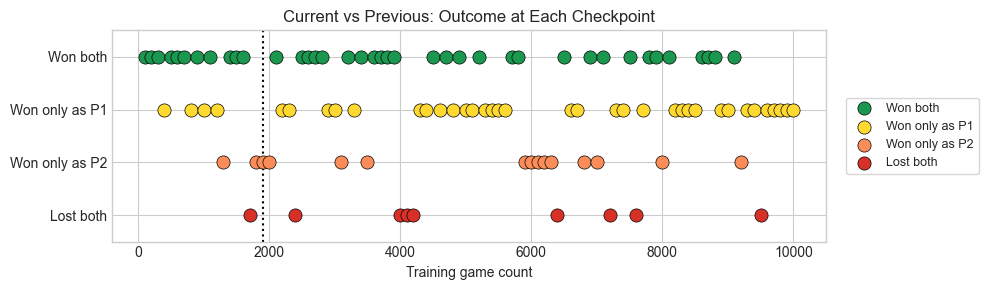

In [8]:
# Plot 2: four-state checkpoint outcome for current vs previous.
# States per checkpoint:
#   - Lost both
#   - Won only as P1
#   - Won only as P2
#   - Won both

cvp_rows = df_raw[df_raw["matchup"] == "current vs previous"].copy()
cvp_rows["perspective"] = np.where(cvp_rows["p1"] == "current", "P1", "P2")
cvp_rows["win_indicator"] = (cvp_rows["current_wins"] > cvp_rows["opponent_wins"]).astype(int)

state_df = (
    cvp_rows.pivot(index="checkpoint", columns="perspective", values="win_indicator")
    .rename(columns={"P1": "win_as_p1", "P2": "win_as_p2"})
    .reset_index()
)

state_df["state_code"] = state_df["win_as_p1"] * 2 + state_df["win_as_p2"]
state_labels = {
    0: "Lost both",
    1: "Won only as P2",
    2: "Won only as P1",
    3: "Won both",
}
state_df["state_label"] = state_df["state_code"].map(state_labels)

# Color map by 4-state outcome.
state_colors = {
    0: "#d73027",  # red
    1: "#fc8d59",  # orange
    2: "#ffd92f",  # yellow
    3: "#1a9850",  # green
}

fig, ax = plt.subplots(figsize=(10, 3))
if best_checkpoint_game is not None:
    ax.axvline(best_checkpoint_game, color="black", linestyle=":", linewidth=1.5, zorder=0)

for code in [0, 1, 2, 3]:
    g = state_df[state_df["state_code"] == code]
    ax.scatter(
        g["checkpoint"],
        g["state_code"],
        s=90,
        color=state_colors[code],
        edgecolor="black",
        linewidth=0.5,
        label=state_labels[code],
    )

ax.set_title("Current vs Previous: Outcome at Each Checkpoint")
ax.set_xlabel("Training game count")
ax.set_ylabel("")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([state_labels[i] for i in [0, 1, 2, 3]])
ax.set_ylim(-0.5, 3.5)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], ncol=1, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.tight_layout()
plt.show()

# state_df[["checkpoint", "state_label", "win_as_p1", "win_as_p2"]]

## Stacked Plots
(specifically for the training output from td_hs256_10k.txt)

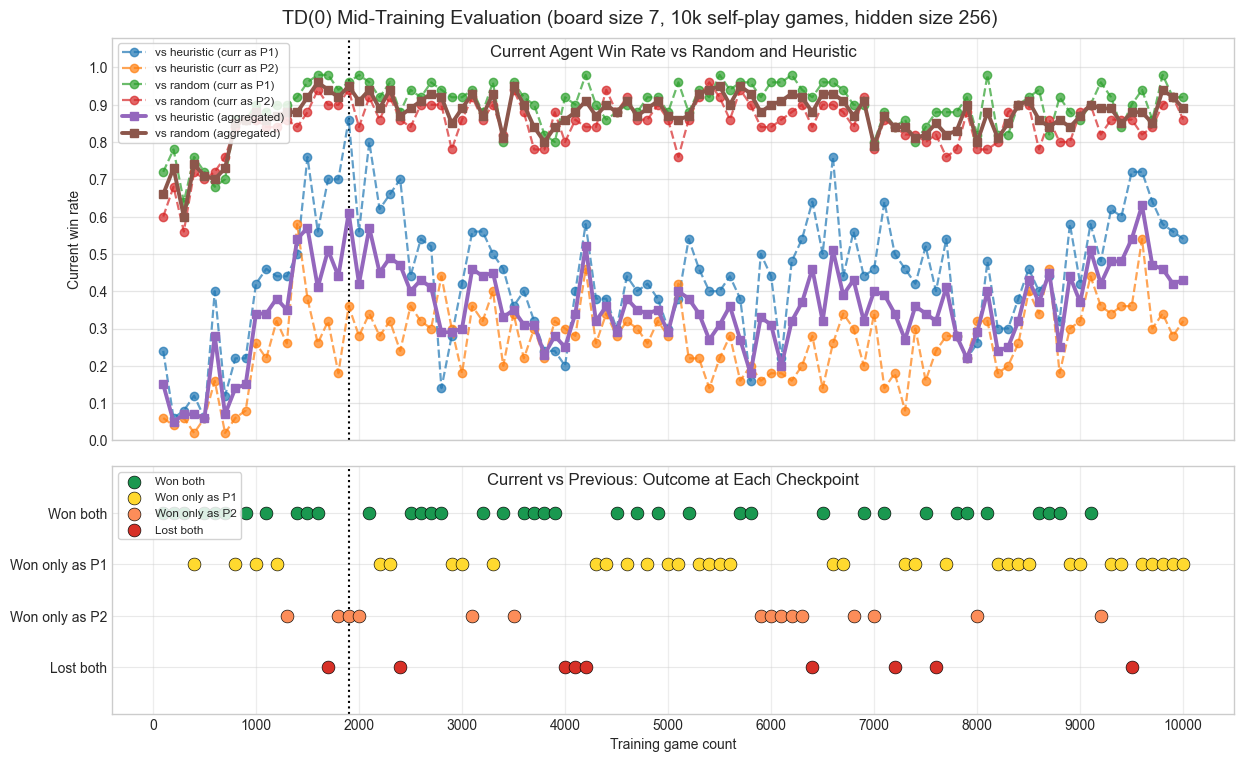

In [19]:
# Plot 3: stacked view of Plot 1 and Plot 2 with a shared model-specific super title.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.35], "hspace": 0.08},
)
ax1, ax2 = axes

if best_checkpoint_game is not None:
    ax1.axvline(best_checkpoint_game, color="black", linestyle=":", linewidth=1.5, zorder=0)
    ax2.axvline(best_checkpoint_game, color="black", linestyle=":", linewidth=1.5, zorder=0)

min_ckpt = int(df_agg["checkpoint"].min())
max_ckpt = int(df_agg["checkpoint"].max())
start_tick = (min_ckpt // 1000) * 1000
xticks_1000 = np.arange(start_tick, max_ckpt + 1000, 1000)
ax1.set_xticks(xticks_1000)
ax2.set_xticks(xticks_1000)

# Top panel: current vs random/heuristic with directional and aggregated win rates.
plot_matchups = ["current vs random", "current vs heuristic"]
matchup_label = {"current vs random": "vs random", "current vs heuristic": "vs heuristic"}
perspective_label = {"Current as P1": "curr as P1", "Current as P2": "curr as P2"}
plot_df_raw = df_raw[df_raw["matchup"].isin(plot_matchups)].copy()
plot_df_agg = df_agg[df_agg["matchup"].isin(plot_matchups)].copy()

plot_df_raw["perspective"] = np.where(plot_df_raw["p1"] == "current", "Current as P1", "Current as P2")
for (matchup, perspective), group in plot_df_raw.groupby(["matchup", "perspective"]):
    ax1.plot(
        group["checkpoint"],
        group["current_win_rate"],
        marker="o",
        linestyle="--",
        alpha=0.7,
        linewidth=1.6,
        zorder=3,
        label=f"{matchup_label[matchup]} ({perspective_label[perspective]})",
    )

for matchup, group in plot_df_agg.groupby("matchup"):
    ax1.plot(
        group["checkpoint"],
        group["current_win_rate"],
        marker="s",
        linewidth=2.8,
        zorder=4,
        label=f"{matchup_label[matchup]} (aggregated)",
    )

ax1.set_title("Current Agent Win Rate vs Random and Heuristic", fontsize=12, y=0.945, pad=2)
ax1.set_ylabel("Current win rate")
ax1.set_ylim(0.0, 1.08)
ax1.set_yticks(np.arange(0.0, 1.01, 0.1))
ax1.grid(axis="y", alpha=0.5, linewidth=0.9)
ax1.grid(axis="x", which="major", alpha=0.34, linewidth=0.9)
ax1.legend(loc="upper left", ncol=1, fontsize=8.5, frameon=True, framealpha=0.85, borderpad=0.35)

# Bottom panel: four-state checkpoint outcomes for current vs previous.
for code in [0, 1, 2, 3]:
    g = state_df[state_df["state_code"] == code]
    ax2.scatter(
        g["checkpoint"],
        g["state_code"],
        s=85,
        color=state_colors[code],
        edgecolor="black",
        linewidth=0.45,
        label=state_labels[code],
    )

ax2.set_title("Current vs Previous: Outcome at Each Checkpoint", fontsize=12, y=0.91, pad=3)
ax2.set_xlabel("Training game count")
ax2.set_ylabel("")
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels([state_labels[i] for i in [0, 1, 2, 3]])
ax2.set_ylim(-0.9, 3.9)
ax2.grid(axis="x", which="major", alpha=0.34, linewidth=0.9)
ax2.grid(axis="y", alpha=0.42, linewidth=0.85)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[::-1], labels[::-1], ncol=1, fontsize=8.5, loc="upper left", frameon=True, framealpha=0.85, borderpad=0.35)

fig.suptitle(
    "TD(0) Mid-Training Evaluation (board size 7, 10k self-play games, hidden size 256)",
    fontsize=14,
    y=0.955,
)
fig.subplots_adjust(left=0.06, right=0.995, bottom=0.075, top=0.92, hspace=0.1)
plt.show()

**Figure caption.** Mid-training TD(0) evaluation on a 7x7 board (10k self-play games, hidden size 256). Top: directional and aggregated win rates vs random and heuristic agents. Bottom: checkpoint outcomes for `current vs previous` (`Lost both`, `Won only as P2`, `Won only as P1`, `Won both`). The dotted line marks checkpoint **1900** (selected best checkpoint), using a rough composite score: `Score ≈ w_prev * WR(current vs previous) + w_heur * WR(current vs heuristic) + w_rand * WR(current vs random)`. Across runs, changing hidden size, number of training games, or using the best checkpoint did not show a consistent impact on performance.